In [13]:
import pandas as pd

movies = pd.read_csv('ml-25m/movies.csv')
ratings = pd.read_csv('ml-25m/ratings.csv')

print('Movies:', movies.shape)
print('Ratings:', ratings.shape)
print()
movies.head()


Movies: (62423, 3)
Ratings: (25000095, 4)



,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [14]:
# How many ratings does each movie have?
ratings_per_movie = ratings.groupby('movieId').size()

print('Total movies:', len(ratings_per_movie))
print('Movies with 50+ ratings:', (ratings_per_movie >= 50).sum())
print('Movies with 100+ ratings:', (ratings_per_movie >= 100).sum())
print()
print('Rating counts distribution:')
print(ratings_per_movie.describe())


Total movies: 59047
Movies with 50+ ratings: 13176
Movies with 100+ ratings: 10326

Rating counts distribution:
count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
dtype: float64


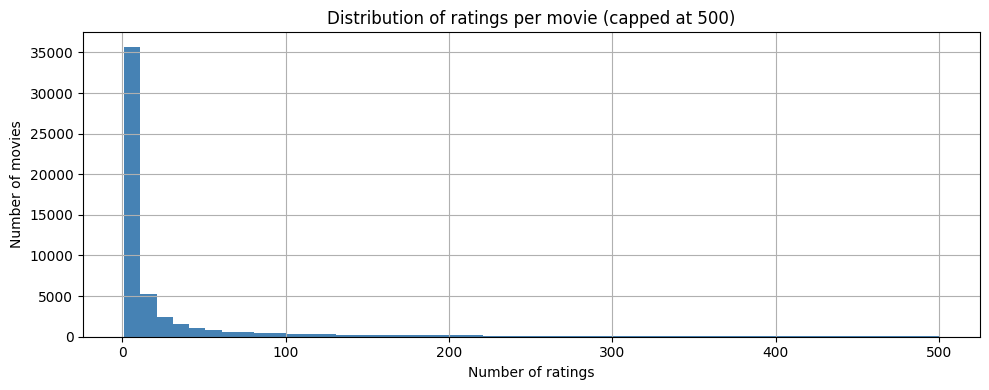


Movies with 1 rating: 10298
Movies with 2-10 ratings: 25392
Movies with 10-50 ratings: 10181
Movies with 50+ ratings: 13176


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Cap at 500 so we can see the shape (otherwise the long tail flattens everything)
ratings_per_movie[ratings_per_movie <= 500].hist(bins=50, color='steelblue', edgecolor='none')

plt.title('Distribution of ratings per movie (capped at 500)')
plt.xlabel('Number of ratings')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.show()

print(f'\nMovies with 1 rating: {(ratings_per_movie == 1).sum()}')
print(f'Movies with 2-10 ratings: {((ratings_per_movie >= 2) & (ratings_per_movie <= 10)).sum()}')
print(f'Movies with 10-50 ratings: {((ratings_per_movie > 10) & (ratings_per_movie < 50)).sum()}')
print(f'Movies with 50+ ratings: {(ratings_per_movie >= 50).sum()}')


In [16]:
# Filter to movies with 50+ ratings
popular_movie_ids = ratings_per_movie[ratings_per_movie >= 50].index
movies_filtered = movies[movies['movieId'].isin(popular_movie_ids)].copy()
ratings_filtered = ratings[ratings['movieId'].isin(popular_movie_ids)].copy()

print('Movies after filter:', len(movies_filtered))
print('Ratings after filter:', len(ratings_filtered))
print()

# Look at the genre format we need to handle
print('Sample genres:')
print(movies_filtered['genres'].head(10).to_string())


Movies after filter: 13176
Ratings after filter: 24644928

Sample genres:
0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
5                          Action|Crime|Thriller
6                                 Comedy|Romance
7                             Adventure|Children
8                                         Action
9                      Action|Adventure|Thriller


In [17]:
# Split all genre strings and find every unique genre
all_genres = movies_filtered['genres'].str.split('|').explode().unique()
all_genres = sorted([g for g in all_genres if g != '(no genres listed)'])

print(f'Total unique genres: {len(all_genres)}')
print()
print(all_genres)


Total unique genres: 19

['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [18]:
movies_filtered.to_csv('ml-25m/movies_filtered.csv', index=False)
ratings_filtered.to_csv('ml-25m/ratings_filtered.csv', index=False)

print('Saved:')
print('  ml-25m/movies_filtered.csv  —', len(movies_filtered), 'movies')
print('  ml-25m/ratings_filtered.csv —', len(ratings_filtered), 'ratings')

Saved:
  ml-25m/movies_filtered.csv  — 13176 movies
  ml-25m/ratings_filtered.csv — 24644928 ratings


In [19]:
ratings_per_user = ratings_filtered.groupby('userId').size()
active_users = ratings_per_user[ratings_per_user >= 50]
print('Active users:', len(active_users))
print('Matrix size:', len(active_users), '×', len(movies_filtered), '=', len(active_users) * len(movies_filtered), 'cells')

Active users: 102293
Matrix size: 102293 × 13176 = 1347812568 cells


In [20]:
for threshold in [50, 100, 200, 500, 1000]:
    active = ratings_per_user[ratings_per_user >= threshold]
    size = len(active) * len(movies_filtered)
    print(f'{threshold}+ ratings: {len(active):>6} users  |  matrix: {size:>12,} cells')

50+ ratings: 102293 users  |  matrix: 1,347,812,568 cells
100+ ratings:  63724 users  |  matrix:  839,627,424 cells
200+ ratings:  32921 users  |  matrix:  433,767,096 cells
500+ ratings:   9556 users  |  matrix:  125,909,856 cells
1000+ ratings:   2560 users  |  matrix:   33,730,560 cells


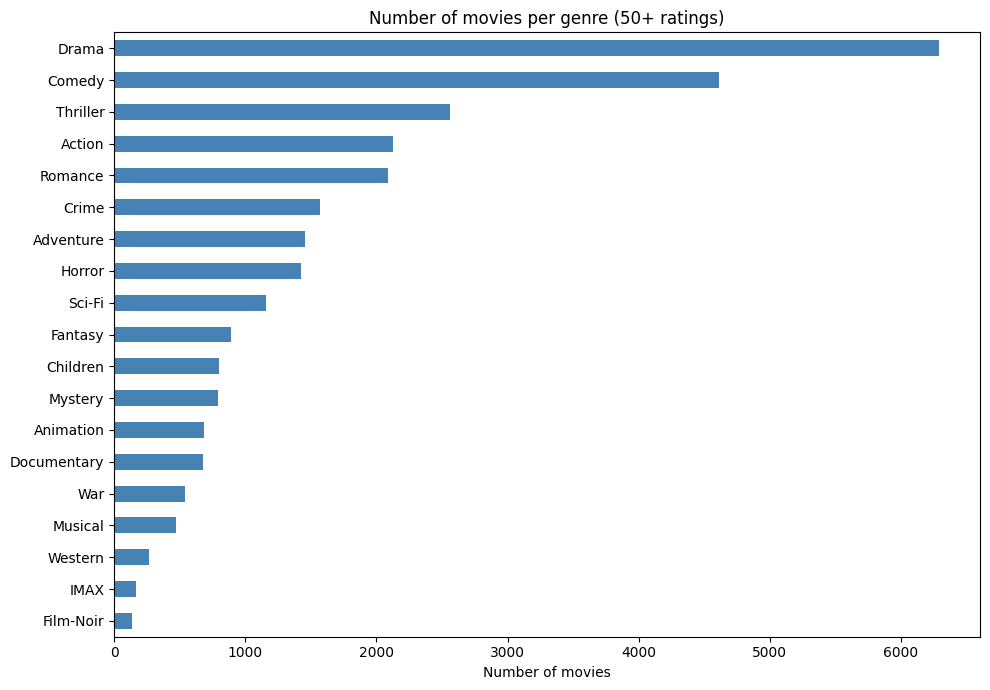

In [22]:
import matplotlib.pyplot as plt

genre_dummies = movies_filtered['genres'].str.get_dummies('|')
if '(no genres listed)' in genre_dummies.columns:
    genre_dummies = genre_dummies.drop(columns=['(no genres listed)'])

genre_counts = genre_dummies.sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
genre_counts.plot(kind='barh', color='steelblue', edgecolor='none')
plt.title('Number of movies per genre (50+ ratings)')
plt.xlabel('Number of movies')
plt.tight_layout()
plt.show()


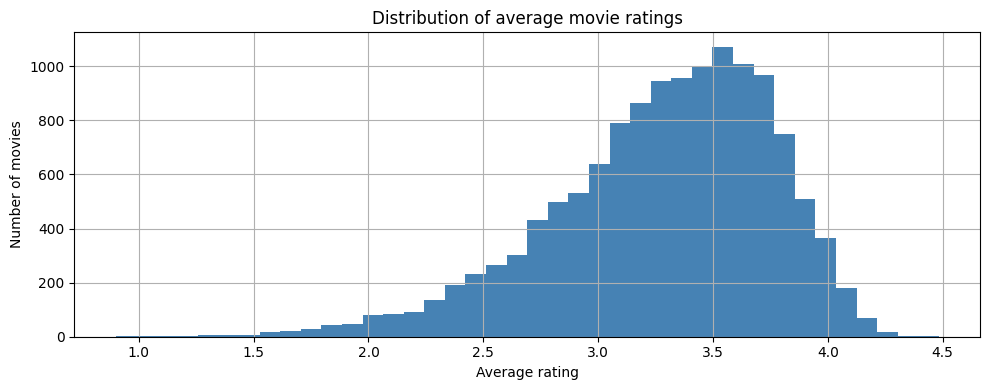

Mean rating: 3.28
Median rating: 3.35
Most common range: 3.50


In [23]:
# Distribution of average ratings per movie
avg_ratings = ratings_filtered.groupby('movieId')['rating'].mean()

plt.figure(figsize=(10, 4))
avg_ratings.hist(bins=40, color='steelblue', edgecolor='none')
plt.title('Distribution of average movie ratings')
plt.xlabel('Average rating')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.show()

print(f'Mean rating: {avg_ratings.mean():.2f}')
print(f'Median rating: {avg_ratings.median():.2f}')
print(f'Most common range: {avg_ratings.mode().values[0]:.2f}')


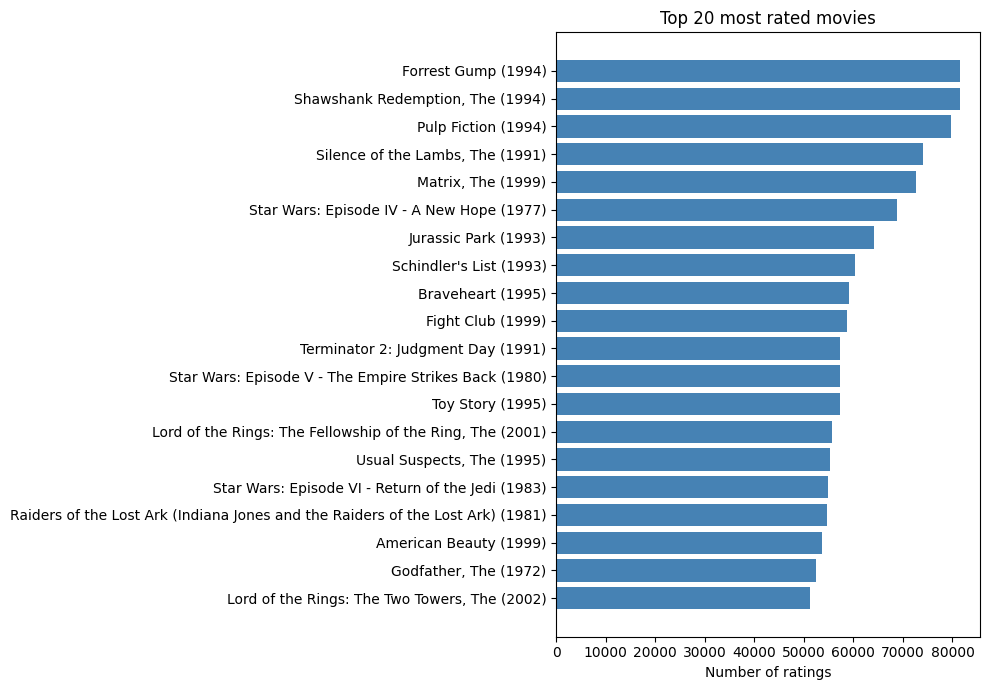

In [24]:
# Top 20 most rated movies
top_rated = (ratings_filtered.groupby('movieId')
             .size()
             .reset_index(name='rating_count')
             .merge(movies_filtered[['movieId', 'title']], on='movieId')
             .sort_values('rating_count', ascending=False)
             .head(20))

plt.figure(figsize=(10, 7))
plt.barh(top_rated['title'], top_rated['rating_count'], color='steelblue', edgecolor='none')
plt.title('Top 20 most rated movies')
plt.xlabel('Number of ratings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
